# Real or Fake: Classification of AI-Generated Synthetic Images

## Image Data Preprocessing

In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay, average_precision_score

In [2]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [3]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [4]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

### Load the Image Dataset

The default class labels is as follows:  
Class 0: Fake  
Class 1: Real  

In [5]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform = transform)

# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

We want to create a validaiton dataset. First we want to get the current proportions of the datasets.

In [6]:
testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

17


Based on the current breakdown on the datasets, 20% of the training data will be used for validation.

In [7]:
validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

True

In [8]:
# need to use the original length of training data to create the validation data
indices = list(range(100000))

random.shuffle(indices)

### Redefine the Training Data and Create Validation Data

In [9]:
# define the indices for training and validation data
trainIndices = indices[:trainingSize]
validationIndices = indices[trainingSize:]

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices)
validationData = Subset(trainingData, validationIndices)

### Create Loaders for Datasets

In [10]:
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
val_loader = DataLoader(validationData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
test_loader = DataLoader(testingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

### Datasets Distribution

In [11]:
# a function that counts the images for each class
def countLabels(data):
    labels = [label for _, label in data]  # get the label
    labelCount = Counter(labels)  # count number of images for each class
    return labelCount


In [12]:
trainCount = countLabels(newTrainingData)
print("Training Data: ")
print(trainCount)
testCount = countLabels(testingData)
print("Testing Data: ")
print(testCount)
validationCount = countLabels(validationData)
print("Validation Data: ")
print(validationCount)

Training Data: 
Counter({1: 40038, 0: 39962})
Testing Data: 
Counter({0: 10000, 1: 10000})
Validation Data: 
Counter({0: 10038, 1: 9962})


### Preview the Images

In [13]:
# a function to display the images
def imgShow(pic):
    # unnormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    pic = pic * std[:, None, None] + mean[:, None, None]
    
    # convert the tensor to numpy
    pic = pic.numpy().transpose((1, 2, 0))
    
    # clip the values
    pic = np.clip(pic, 0, 1)
    
    plt.imshow(pic)
    plt.axis('off')
    plt.show()


#### Training Data

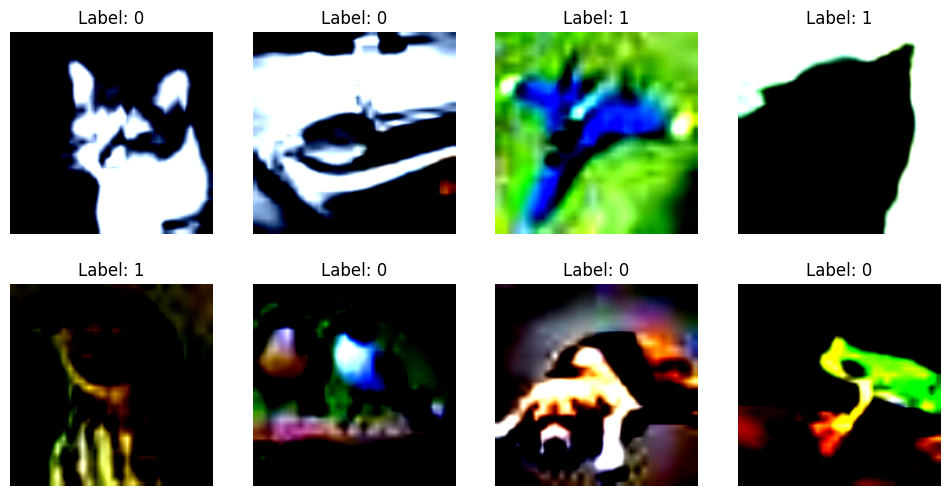

In [14]:
# get a batch of images and labels from the train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()


#### Validation Data

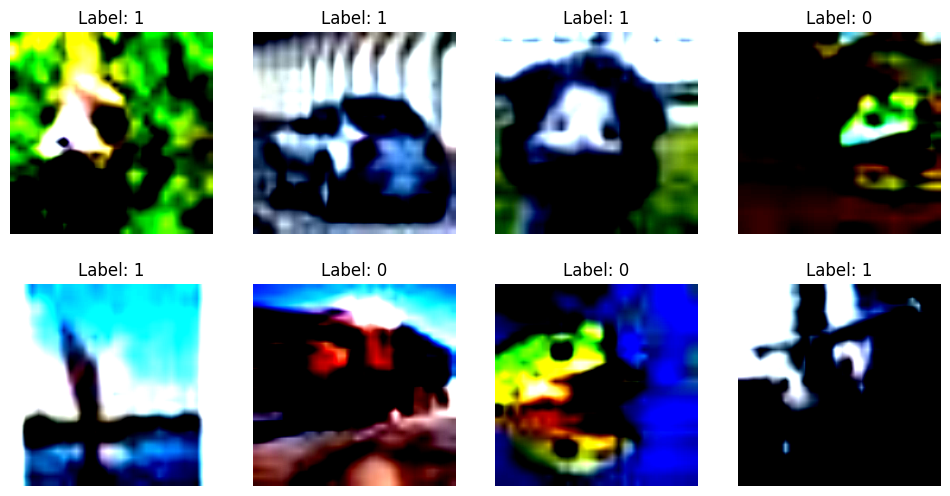

In [15]:
data_iter = iter(val_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

#### Testing Data

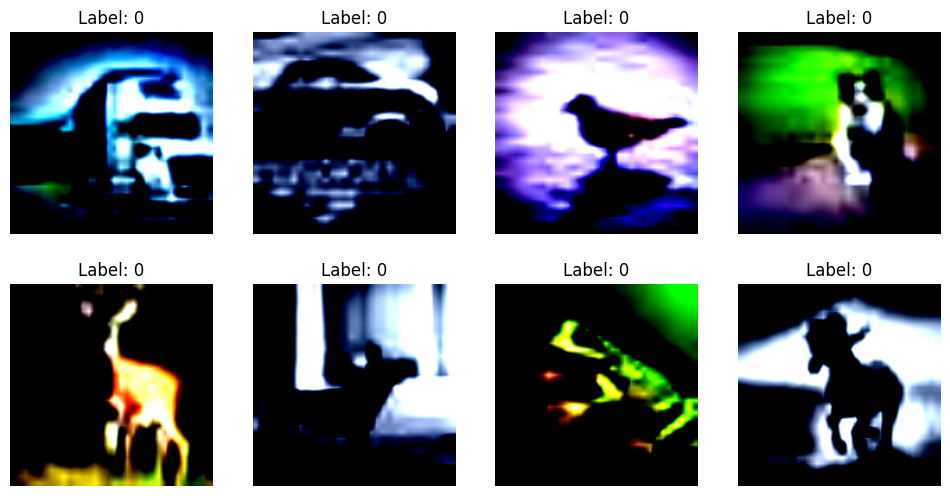

In [16]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

## VGG-16 Model

In [17]:
# use a pretrained VGG-16 model
model_VGG16 = models.vgg16(pretrained = True)

# define the number of class (in the case, 2)
numClasses = 2
model_VGG16.classifier[6] = nn.Linear(in_features = 4096, out_features = numClasses)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 195MB/s]


In [18]:
# try to run the model on GPU
config = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# run the model
model_VGG16 = model_VGG16.to(config)

In [19]:
# define the optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_VGG16.parameters(), lr = 0.01)


# training loop for the model
epochs = 5
for epoch in range(1, epochs+1):
    model_VGG16.train()
    runningLoss = 0
    correct = 0
    total = 0
    print("------------------------------")
    print("Epoch: " + str(epoch))
    # loop through the training data
    for images, labels in train_loader:
        images, labels = images.to(config), labels.to(config)

        # set zero to the gradients
        optimizer.zero_grad()

        outputs = model_VGG16(images)
        # compute the loss
        loss = criterion(outputs, labels)

        # compute the gradient
        loss.backward()
        # update the model weight
        optimizer.step()

        # compute the accuracy
        _, prediction = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (prediction == labels).sum().item()

        runningLoss += loss.item()
    
    # compute the training accuracy
    trainingAccuracy = 100 * correct / total
    trainingLoss = runningLoss / len(train_loader)
    print("Training Accuracy: " + str(trainingAccuracy))
    print("Training Loss:" + str(trainingLoss))

    # perform validation for the model
    model_VGG16.eval()
    validationLoss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(config), labels.to(config)

            outputs = model_VGG16(images)
            # compute the loss
            loss = criterion(outputs, labels)
            validationLoss += loss.item()

            # compute the accuracy
            _, prediction = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (prediction == labels).sum().item()
    # compute the validation accuracy
    validationAccuracy = 100 * correct / total
    validationLoss = runningLoss / len(val_loader)

    print("Validation Accuracy: " + str(validationAccuracy))
    print("Validation Loss:" + str(validationLoss))
    print("------------------------------")

------------------------------
Epoch: 1
Training Accuracy: 92.8225
Training Loss:0.17758730394914746
Validation Accuracy: 96.51
Validation Loss:0.7103492157965898
------------------------------
------------------------------
Epoch: 2
Training Accuracy: 96.7325
Training Loss:0.08638535677436739
Validation Accuracy: 96.78
Validation Loss:0.34554142709746954
------------------------------
------------------------------
Epoch: 3
Training Accuracy: 97.84125
Training Loss:0.057478015807201153
Validation Accuracy: 96.79
Validation Loss:0.22991206322880461
------------------------------
------------------------------
Epoch: 4
Training Accuracy: 98.4575
Training Loss:0.0419401319371711
Validation Accuracy: 97.285
Validation Loss:0.1677605277486844
------------------------------
------------------------------
Epoch: 5
Training Accuracy: 98.9325
Training Loss:0.02927490811672178
Validation Accuracy: 97.605
Validation Loss:0.11709963246688712
------------------------------


In [20]:
# use the testing data for the model
model_VGG16.eval()
trueLabels = []
predictedLabels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(config), labels.to(config)
        outputs = model_VGG16(images)

        _, prediction = torch.max(outputs, 1)

        trueLabels.extend(labels.cpu().numpy())
        predictedLabels.extend(prediction.cpu().numpy())


#### Model Metrics

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     10000
           1       0.98      0.97      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



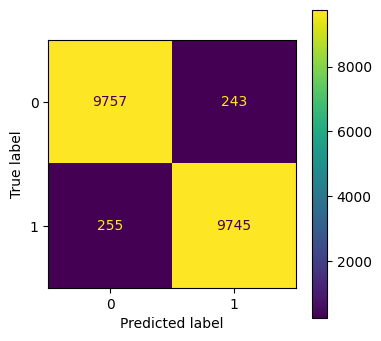

In [21]:
# compile a classification report and confusion matrix
print("Classification Report:")
print(classification_report(trueLabels, predictedLabels))

# define the confusion matrix
confusionMatrix = confusion_matrix(trueLabels, predictedLabels)

# display the matrix
confusionMatrixPlot = ConfusionMatrixDisplay(confusion_matrix = confusionMatrix)
plt.figure(figsize=(4, 4))
confusionMatrixPlot.plot(ax=plt.gca())
plt.show()

In [22]:
# compute the AUC value
aucValue = roc_auc_score(trueLabels, predictedLabels)

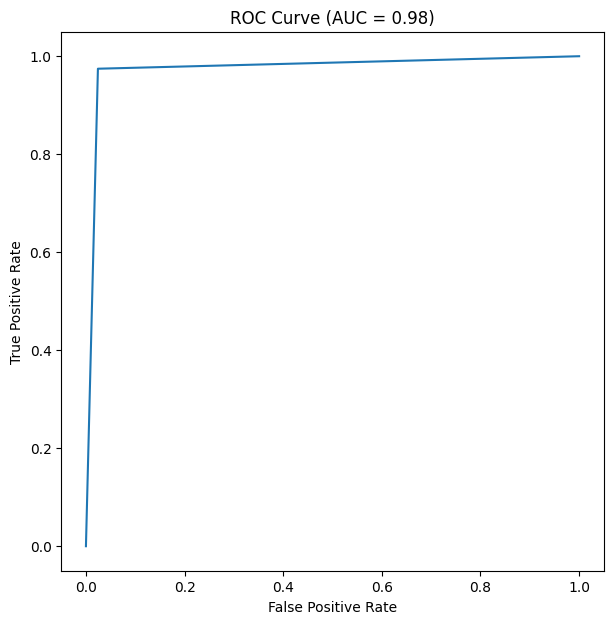

In [23]:
# plot the ROC
fpr, tpr, _ = roc_curve(trueLabels, predictedLabels)
plt.figure(figsize=(7, 7))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_display.plot(ax=plt.gca())
plt.title(f"ROC Curve (AUC = {aucValue:.2f})")
plt.show()

In [24]:
# compute the precision and recall
precision, recall, thresholds = precision_recall_curve(trueLabels, predictedLabels)
average_precision = average_precision_score(trueLabels, predictedLabels)

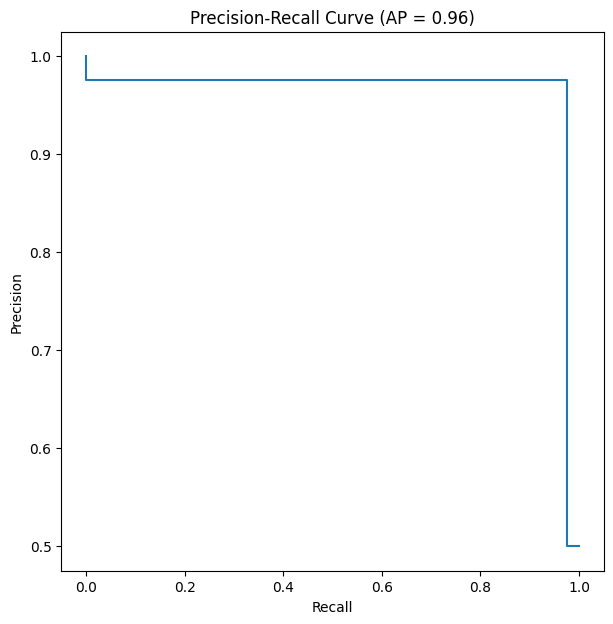

In [25]:
# plot the PRC
fpr, tpr, _ = roc_curve(trueLabels, predictedLabels)
plt.figure(figsize=(7, 7))
PRC_display = PrecisionRecallDisplay(precision= precision, recall=recall)
PRC_display.plot(ax=plt.gca())
plt.title(f"Precision-Recall Curve (AP = {average_precision:.2f})")
plt.show()